Project Option 1: Real-world applications of GNNs

In [1]:
pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.4 MB/s eta 0:00:00


In [2]:
#loading libraries
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch.nn import Dropout

from torch_geometric.datasets import Amazon
from torch_geometric.transforms import NormalizeFeatures

# Load the Amazon Computers dataset
dataset = Amazon(root=".", name="Computers", transform=NormalizeFeatures())
data = dataset[0]





Processing...
Done!


In [3]:
import torch

# Assuming a split of 80% training, 10% validation, and 10% testing
num_nodes = data.num_nodes
train_mask = torch.rand(num_nodes) < 0.8
remaining = ~train_mask  # nodes not in the train set
val_mask = torch.rand(num_nodes) < 0.5 * remaining  # 50% of remaining nodes for validation
test_mask = remaining & ~val_mask  # remaining nodes for test

data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask


In [4]:
print(f"Training nodes: {data.train_mask.sum().item()}")
print(f"Validation nodes: {data.val_mask.sum().item()}")
print(f"Test nodes: {data.test_mask.sum().item()}")


Training nodes: 11100
Validation nodes: 1314
Test nodes: 1338


I build a Graph Convolutional Network (GCN) model with three GCN layers and dropout for regularization.

    Attributes:
        conv1 (GCNConv): The first GCN layer that takes the input features and outputs to the hidden layer.
        conv2 (GCNConv): The second GCN layer that applies a hidden-to-hidden transformation.
        conv3 (GCNConv): The third GCN layer that produces the output logits.
        dropout (Dropout): Dropout layer to prevent overfitting during training.



In [5]:
class OriginalGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout_rate=0.5):
        super(OriginalGCN, self).__init__()
        # Define three GCN layers
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, out_channels)

        # Dropout for regularization
        self.dropout = Dropout(dropout_rate)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # First GCN layer with ReLU and dropout
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)

        # Second GCN layer with skip connection and dropout
        x = F.relu(self.conv2(x, edge_index)) + x
        x = self.dropout(x)

        # Third GCN layer (output layer)
        x = self.conv3(x, edge_index)

        return F.log_softmax(x, dim=1)




In [6]:
# Instantiate the model, define the optimizer and loss function
model = OriginalGCN(in_channels=767, hidden_channels=64, out_channels= 10, dropout_rate=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# Training and evaluation functions
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def test(mask):
    model.eval()
    with torch.no_grad():
        out = model(data)
        pred = out[mask].max(1)[1]
        correct = pred.eq(data.y[mask]).sum().item()
        acc = correct / mask.sum().item()
    return acc


In [7]:
# Lists to store metrics
train_losses = []
train_accuracies = []
val_accuracies = []
test_accuracies = []


In [8]:
# Training loop
epochs = 200
for epoch in range(epochs):
    train_loss = train()  # Call to the train function
    train_acc = test(data.train_mask)
    val_acc = test(data.val_mask)
    test_acc = test(data.test_mask)

    # Store the metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    test_accuracies.append(test_acc)

    print(f'Epoch: {epoch:03d}, Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}')


Epoch: 000, Loss: 2.3029, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 001, Loss: 2.2658, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 002, Loss: 2.2184, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 003, Loss: 2.1581, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 004, Loss: 2.0867, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 005, Loss: 2.0161, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 006, Loss: 1.9651, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 007, Loss: 1.9489, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 008, Loss: 1.9662, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 009, Loss: 1.9788, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 010, Loss: 1.9649, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 011, Loss: 1.9566, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 012, Loss: 1.9445, Train Acc: 0.3750, Val Acc

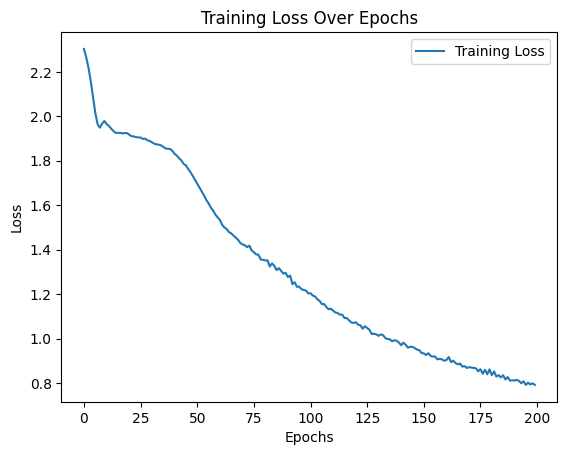

In [9]:
import matplotlib.pyplot as plt

# Plot training loss
plt.figure()
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.show()

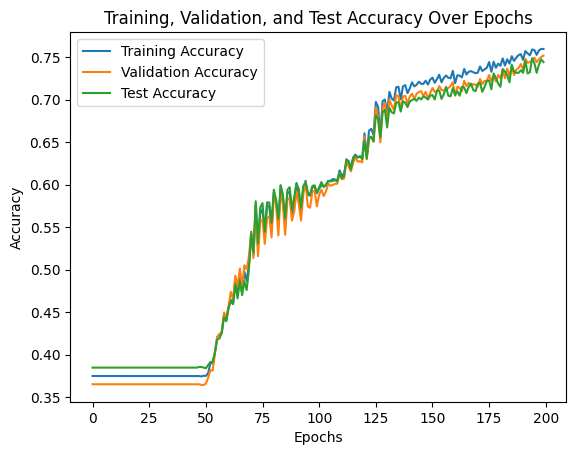

In [10]:
# Plot training, validation, and test accuracies
plt.figure()
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training, Validation, and Test Accuracy Over Epochs')
plt.legend()
plt.show()

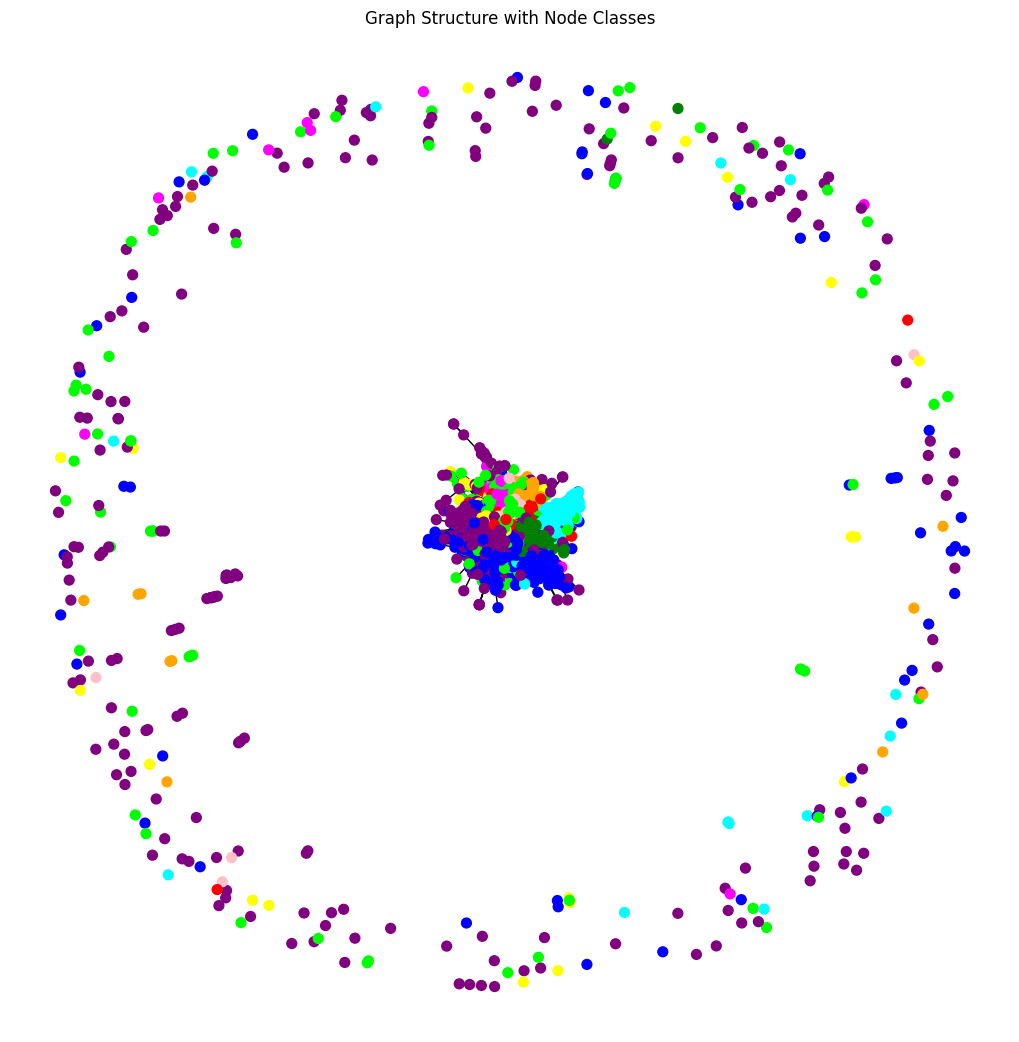

In [12]:
#loading libraries
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

# Convert the graph to a NetworkX format for visualization
G = to_networkx(data, to_undirected=True)

# Define color mapping for each classes
color_map = ['red', 'blue', 'green', 'yellow', 'purple', 'orange', 'pink', 'cyan', 'lime', 'magenta']
node_colors = [color_map[label] for label in data.y]  # Assign colors based on predicted labels

# Plot the graph
plt.figure(figsize=(10, 10))
nx.draw(G, node_color=node_colors, with_labels=False, node_size=50)
plt.title("Graph Structure with Node Classes")
plt.show()


Model with Two GCN Layers Only

Documentation of model.
A two-layer Graph Convolutional Network (GCN) for node classification tasks.

    Attributes:
        conv1 (GCNConv): The first GCN layer, which transforms the input features to hidden representations.
        conv2 (GCNConv): The second GCN layer, which transforms the hidden representations to output logits.
        dropout (Dropout): Dropout layer for regularization applied after the first GCN layer.


In [13]:
class GCN_TwoLayers(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout_rate=0.5):
        super(GCN_TwoLayers, self).__init__()
        # First GCN layer that takes input features and transforms them to hidden representations.
        self.conv1 = GCNConv(in_channels, hidden_channels)
         # Second GCN layer that transforms hidden representations to the final output logits for each class.
        self.conv2 = GCNConv(hidden_channels, out_channels)
        # Dropout layer to prevent overfitting
        self.dropout = Dropout(dropout_rate)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
         # Apply the first GCN layer with ReLU activation, followed by dropout
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        # Apply the second GCN layer to produce the output logits.
        x = self.conv2(x, edge_index)
         # Return log softmax of the output logits for multi-class classification.
        return F.log_softmax(x, dim=1)


In [14]:
# Instantiate the model, define the optimizer and loss function
model = GCN_TwoLayers(in_channels=767, hidden_channels=64, out_channels= 10, dropout_rate=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# Training and evaluation functions
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def test(mask):
    model.eval()
    with torch.no_grad():
        out = model(data)
        pred = out[mask].max(1)[1]
        correct = pred.eq(data.y[mask]).sum().item()
        acc = correct / mask.sum().item()
    return acc

In [15]:
# Lists to store metrics
train_losses = []
train_accuracies = []
val_accuracies = []
test_accuracies = []


# Training loop
epochs = 200
for epoch in range(epochs):
    train_loss = train()  # Call to the train function
    train_acc = test(data.train_mask)
    val_acc = test(data.val_mask)
    test_acc = test(data.test_mask)

    # Store the metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    test_accuracies.append(test_acc)

    print(f'Epoch: {epoch:03d}, Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}')


Epoch: 000, Loss: 2.3033, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 001, Loss: 2.2757, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 002, Loss: 2.2435, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 003, Loss: 2.2056, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 004, Loss: 2.1660, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 005, Loss: 2.1234, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 006, Loss: 2.0812, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 007, Loss: 2.0415, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 008, Loss: 2.0072, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 009, Loss: 1.9803, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 010, Loss: 1.9596, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 011, Loss: 1.9488, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 012, Loss: 1.9364, Train Acc: 0.3750, Val Acc

Model Without Skip Connections


Documentation of model: A three-layer Graph Convolutional Network (GCN) without skip connections for node classification tasks.

    Attributes:
        conv1 (GCNConv): The first GCN layer, which transforms input features to hidden representations.
        conv2 (GCNConv): The second GCN layer, which transforms hidden representations.
        conv3 (GCNConv): The third GCN layer, which produces output logits for each class.
        dropout (Dropout): Dropout layer for regularization, applied after the first and second GCN layers.


In [16]:
class GCN_NoSkipConnections(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout_rate=0.5):
        super(GCN_NoSkipConnections, self).__init__()
        # First GCN layer that takes input features and transforms them to hidden representations.
        self.conv1 = GCNConv(in_channels, hidden_channels)
        # Second GCN layer that further transforms hidden representations.
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
         # Third GCN layer that produces output logits for each class.
        self.conv3 = GCNConv(hidden_channels, out_channels)
        # Dropout layer to prevent overfitting, applied after the first and second GCN layers.
        self.dropout = Dropout(dropout_rate)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
         # Apply the first GCN layer with ReLU activation, followed by dropout
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        # Apply the third GCN layer to produce the output logits.
        x = F.relu(self.conv2(x, edge_index))
        x = self.dropout(x)
        # Apply the third GCN layer to produce the output logits.
        x = self.conv3(x, edge_index)
        # Return log softmax of the output logits for multi-class classification.
        return F.log_softmax(x, dim=1)


In [17]:
# Instantiate the model, define the optimizer and loss function
model = GCN_NoSkipConnections(in_channels=767, hidden_channels=64, out_channels= 10, dropout_rate=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# Training and evaluation functions
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def test(mask):
    model.eval()
    with torch.no_grad():
        out = model(data)
        pred = out[mask].max(1)[1]
        correct = pred.eq(data.y[mask]).sum().item()
        acc = correct / mask.sum().item()
    return acc

In [18]:
# Lists to store metrics
train_losses = []
train_accuracies = []
val_accuracies = []
test_accuracies = []


# Training loop
epochs = 200
for epoch in range(epochs):
    train_loss = train()  # Call to the train function
    train_acc = test(data.train_mask)
    val_acc = test(data.val_mask)
    test_acc = test(data.test_mask)

    # Store the metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    test_accuracies.append(test_acc)

    print(f'Epoch: {epoch:03d}, Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}')


Epoch: 000, Loss: 2.3026, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 001, Loss: 2.2752, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 002, Loss: 2.2357, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 003, Loss: 2.1855, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 004, Loss: 2.1250, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 005, Loss: 2.0571, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 006, Loss: 1.9990, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 007, Loss: 1.9633, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 008, Loss: 1.9537, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 009, Loss: 1.9709, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 010, Loss: 1.9862, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 011, Loss: 1.9726, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 012, Loss: 1.9585, Train Acc: 0.3750, Val Acc

Comparison between model architectures

comparing to existing GCN model from DataCamp(External source)

Documentation of model: A two-layer Graph Convolutional Network (GCN) for node classification, based on an existing external GCN model.

    Attributes:
        conv1 (GCNConv): The first GCN layer that transforms input features to hidden representations.
        conv2 (GCNConv): The second GCN layer that produces output logits for each class.
        dropout_rate (float): The dropout rate used for regularization.


In [19]:
# comparing to existing GCN model from DataCamp(External source)
class GCN_Comparison(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout_rate=0.5):
        super(GCN_Comparison, self).__init__()
         # Set random seed for reproducibility.
        torch.manual_seed(1234567)
        # First GCN layer that transforms input features to hidden representations.
        self.conv1 = GCNConv(in_channels, hidden_channels)
        # Second GCN layer that produces output logits for each class.
        self.conv2 = GCNConv(hidden_channels, out_channels)
        # Dropout rate to prevent overfitting.
        self.dropout_rate = dropout_rate

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        # Apply the first GCN layer with ReLU activation.
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)
        # Apply the second GCN layer to produce the output logits.
        x = self.conv2(x, edge_index)
        # Return log softmax of the output logits for multi-class classification.
        return F.log_softmax(x, dim=1)

In [20]:
# Instantiate the model, define the optimizer and loss function
model = GCN_Comparison(in_channels=dataset.num_features, hidden_channels=64, out_channels=dataset.num_classes, dropout_rate=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# Training and evaluation functions
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def test(mask):
    model.eval()
    with torch.no_grad():
        out = model(data)
        pred = out[mask].max(1)[1]
        correct = pred.eq(data.y[mask]).sum().item()
        acc = correct / mask.sum().item()
    return acc

In [21]:
# Lists to store metrics over epochs
train_losses = []
train_accuracies = []
val_accuracies = []
test_accuracies = []

# Training loop
epochs = 200
for epoch in range(epochs):
    train_loss = train()  # Call to the train function
    train_acc = test(data.train_mask)
    val_acc = test(data.val_mask)
    test_acc = test(data.test_mask)

    # Store the metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    test_accuracies.append(test_acc)

    print(f'Epoch: {epoch:03d}, Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}')


Epoch: 000, Loss: 2.3033, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 001, Loss: 2.2810, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 002, Loss: 2.2540, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 003, Loss: 2.2226, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 004, Loss: 2.1875, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 005, Loss: 2.1497, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 006, Loss: 2.1097, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 007, Loss: 2.0728, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 008, Loss: 2.0377, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 009, Loss: 2.0057, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 010, Loss: 1.9776, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 011, Loss: 1.9574, Train Acc: 0.3750, Val Acc: 0.3653, Test Acc: 0.3849
Epoch: 012, Loss: 1.9439, Train Acc: 0.3750, Val Acc